# Example: Binomial Lattice Terminal-Target Probabilities
Suppose we buy shares and plan to sell them after a chosen holding period. What is the probability that our discounted return exceeds a target? In this example, we apply the NPV framework from the L4a lecture to answer that question. We will estimate binomial lattice parameters from historical stock data, construct the price distribution, and compute the probability that the scaled NPV exceeds our target at the scheduled sale time. We will also compare the probabilities for several target returns.

> __Learning Objectives__
>
> By the end of this example, you will be able to:
>
> * **Estimate binomial lattice parameters from historical data.** Use observed growth rates to calculate representative up and down factors and estimate the probability of an up move.
> * **Construct a binomial price lattice.** Use the estimated parameters and an initial share price to calculate possible future prices and their probabilities over a chosen holding period.
> * **Compute probabilities for terminal return targets.** Identify the minimum number of up moves needed to exceed a target scaled NPV, then calculate the probabilities of finishing above or at or below that target.

Let's get started!

___


## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines local paths, and loads the packages used here.

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # load the local notebook setup

  Activating 

project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the functions and types used here.

### Data
The dataset contains daily open-high-low-close (OHLC) records for firms in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from 2014-01-03 through 2024-12-31, along with records for several exchange-traded funds and volatility products.

Let's load the data using the [`MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet). We store the result in `original_dataset`, a dictionary whose keys are ticker symbols and whose values are `DataFrame` tables containing each ticker's price history.

In [2]:
original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"];

Not all tickers have the same number of observations. For this example, let's keep price histories of equal length. We use `AAPL` as our reference and store its number of records in `maximum_number_trading_days`. We will then retain tickers with that same number of records.

In [3]:
maximum_number_trading_days = original_dataset["AAPL"] |> nrow # nrow? (check out: DataFrames.jl)

2767

Now, let's iterate through our data and collect only tickers with `maximum_number_trading_days` records. We'll save that data in the `dataset::Dict{String,DataFrame}` variable:

In [4]:
dataset = let

    # initialize -
    dataset = Dict{String, DataFrame}();

    # Retain firms that share the complete trading calendar -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

How many firms do we have with the full number of trading days? Let's use [the `length(...)` function](https://docs.julialang.org/en/v1/base/collections/#Base.length), which works for dictionaries in addition to arrays, sets, and other collections.

In [5]:
length(dataset) # tells us how many keys are in the dictionary (how many firms in our dataset?)

424

Finally, let's get a list of the firms in our cleaned dataset and sort them alphabetically. We store the sorted firm ticker symbols in the `list_of_tickers::Array{String,1}` variable.

In [6]:
list_of_tickers = keys(dataset) |> collect |> sort # list of firm "ticker" symbols in alphabetical order

424-element Vector{String}:
 "A"
 "AAL"
 "AAP"
 "AAPL"
 "ABBV"
 "ABT"
 "ACN"
 "ADBE"
 "ADI"
 "ADM"
 "ADP"
 "ADSK"
 "AEE"
 ⋮
 "WST"
 "WU"
 "WY"
 "WYNN"
 "XEL"
 "XOM"
 "XRAY"
 "XYL"
 "YUM"
 "ZBRA"
 "ZION"
 "ZTS"

### Constants
Finally, let's set some constants we'll use later in this notebook. The comments describe the constants, their units, and permissible values.

In [7]:
TSIM = 63; # number of trading days to simulate
Δt = (1.0/252); # step size: 1 trading day in units of years
g_y = 0.05; # continuous annual rate for the selected benchmark yield y (1/years)

___

## Task 1: Estimate lattice parameters from historical data
In this task, we estimate the three parameters $p$, $u$, and $d$ needed to construct the binomial price lattice.

> __Parameter Definitions__
>
>* The $p$ parameter represents the probability of a share price increase or an `up` move between two consecutive periods $j\rightarrow{j+1}$. Since a binary lattice model only allows `up` and `down` moves, the probability of a `down` move is $1-p$.
>* The $u$ parameter represents the magnitude of an `up` move. If $S_{j}$ denotes the share price in period $j$, and $S_{j+1}$ is the share price in the next period, then an `up` move results in $S_{j+1} = u\cdot{S}_{j}$.
>* The $d$ parameter represents the magnitude of a `down` move. If $S_{j}$ denotes the share price in period $j$, and $S_{j+1}$ is the share price in the next period, then a `down` move results in $S_{j+1} = d\cdot{S}_{j}$.

To start, let's select a firm from the dataset to explore.

In [8]:
selected_firm_ticker = "ADBE" # fixed ticker for reproducibility
selected_firm_index = findfirst(==(selected_firm_ticker), list_of_tickers)
selected_firm_data = dataset[selected_firm_ticker]

Row,volume,volume_weighted_average_price,open,close,high,low,timestamp,number_of_transactions
,Float64,Float64,Float64,Float64,Float64,Float64,DateTime,Int64
1,1.58864e6,59.3388,59.19,59.16,59.685,59.11,2014-01-03T05:00:00,13477
2,3.75391e6,58.2928,58.06,58.12,58.77,58.01,2014-01-06T05:00:00,27434
3,2.96361e6,58.5869,58.26,58.97,59.05,58.06,2014-01-07T05:00:00,22544
4,3.45596e6,58.9278,59.12,58.9,59.28,58.46,2014-01-08T05:00:00,25309
5,2.42743e6,59.157,58.99,59.09,59.53,58.72,2014-01-09T05:00:00,18370
6,1.82906e6,59.3491,59.35,59.53,59.63,58.95,2014-01-10T05:00:00,15386
7,2.92875e6,58.8357,59.28,58.6,59.44,58.41,2014-01-13T05:00:00,24879
8,4.18005e6,60.0286,58.68,60.37,60.53,58.63,2014-01-14T05:00:00,25884
9,4.22034e6,61.4091,60.44,61.68,61.81,60.4,2014-01-15T05:00:00,30992


### Estimate the $u$, $d$, and $p$ parameters from the data
Let's start by computing the growth rates for our selected firm. For consecutive observed prices $S_{j-1}$ and $S_j$, the annualized log-growth rate is:

$$
g_j=\frac{1}{\Delta t}\ln\!\left(\frac{S_j}{S_{j-1}}\right).
$$

Here, we use the volume-weighted average price (VWAP) for each trading day and $\Delta t=1/252$ years. A positive growth rate indicates a price increase; a negative value indicates a decrease. The corresponding price-change factor is $e^{g_j\Delta t}=S_j/S_{j-1}$.

We compute these growth rates using `log_growth_matrix(dataset, selected_firm_ticker)` and store them in `log_growth_array`. We will use the positive and negative observations to estimate the lattice parameters.

In [9]:
log_growth_array = log_growth_matrix(dataset, selected_firm_ticker) # array holding growth rate time series

2766-element Vector{Float64}:
  -4.48177101721035
   1.2681989501752422
   1.4620645924022435
   0.9782541450394576
   0.816991570922429
  -2.189412070255259
   5.058220052146569
   5.729703164907576
   0.8144832602206464
  -1.3941711674103718
  -1.1683502506700052
   2.0363580890577953
  -2.8152388299854025
   ⋮
 -10.318765952539094
   1.193236717285588
  -4.558776434053768
  -4.775255302688766
  -3.634169535759943
   1.4308473355847118
   1.1050283272038928
  -0.01619378627487112
   1.939109727885214
  -2.805837196438786
  -0.3660345335453977
   0.3514260052939249

Now, let's use these growth rates to estimate one representative up factor, one representative down factor, and the probability of an up move:

1. For positive growth rates, compute the factors $e^{g_j\Delta t}$ and average them to obtain $\bar u$.
2. For negative growth rates, compute the factors $e^{g_j\Delta t}$ and average them to obtain $\bar d$.
3. Estimate $\bar p$ by dividing the number of positive growth observations by the total number of growth observations.

Zero-growth observations do not enter either factor average, but the estimator includes them in the total observation count used for $\bar p$.

We perform this calculation by passing `log_growth_array` to a `RealWorldBinomialProbabilityMeasure` instance. The call returns the estimates $(\bar u,\bar d,\bar p)$, which we store in `(ū, d̄, p̄)`.

In [10]:
(ū,d̄,p̄) = let

    # initialize -
    u = nothing; 
    d = nothing; 
    p = nothing; 

    (u,d,p) = (RealWorldBinomialProbabilityMeasure())(log_growth_array; Δt = Δt)
    
    (u,d,p); # return
end;

Let's create a table for the binomial lattice parameters:

In [11]:
let

    # initialize -
    df = DataFrame();

    row_df = (
        ticker = selected_firm_ticker,
        upfactor = ū,
        downfactor = d̄,
        probability = p̄,
    );
    push!(df, row_df);

      # display the table -
    pretty_table(df, 
         table_format = TextTableFormat(borders = text_table_borders__compact));    
    
end

 -------- ---------- ------------ -------------
  ticker   upfactor   downfactor   probability 
  String    Float64      Float64       Float64 
 -------- ---------- ------------ -------------
    ADBE    1.01165     0.987349      0.556761
 -------- ---------- ------------ -------------


Let's look at the distribution of annualized log-growth rates for our selected firm. The histogram shows the range of historical observations that we summarize using just two price-change factors in our binomial model.

In [12]:
UnicodePlots.histogram(log_growth_array, nbins=25, closed=:left)

                  ┌                                        ┐ 
   [-45.0, -40.0) ┤▏ 1                                       
   [-40.0, -35.0) ┤  0                                       
   [-35.0, -30.0) ┤▏ 1                                       
   [-30.0, -25.0) ┤▏ 1                                       
   [-25.0, -20.0) ┤▎ 5                                       
   [-20.0, -15.0) ┤▍ 12                                      
   [-15.0, -10.0) ┤▊ 31                                      
   [-10.0,  -5.0) ┤█████▏ 196                                
   [ -5.0,   0.0) ┤█████████████████████████▎ 979            
   [  0.0,   5.0) ┤█████████████████████████████████  1 281  
   [  5.0,  10.0) ┤█████▋ 223                                
   [ 10.0,  15.0) ┤▌ 22                                      
   [ 15.0,  20.0) ┤▍ 11                                      
   [ 20.0,  25.0) ┤▏ 3                                       
                  └                                        ┘ 
        

### Build binomial lattice model using historical parameters
Let's construct an instance of [the `MyBinomialEquityPriceTree` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.MyBinomialEquityPriceTree) using the estimated values for the parameters ($\bar{u}$, $\bar{d}$, $\bar{p}$) from above. 

This will enable us to calculate the prices and probabilities in the tree. We store the populated model in the variable `selected_test_model` for future use.

First, specify the `start_index::Int64` as the trading day index in the dataset, which will serve as the tree's starting point or `L = 0`. For reproducibility, let's hard-code this value as `start_index = 1187`, which corresponds to the trading day `2018-09-19` for our dataset.

Here, we use the full historical sample to estimate the lattice parameters, including observations after our chosen starting date. This example illustrates the calculation using those estimates. To make a forecast from the selected date, we would estimate the parameters using only the observations available at that time.


In [13]:
start_index = 1187; # DO NOT CHANGE hardcoded start-time for reproducibility
stop_index = start_index + TSIM # TSIM defines the number of trading days to simulate
println("Visualize $(selected_firm_ticker) between trading days ($(start_index) -> $(stop_index))")

Visualize ADBE between trading days (1187 -> 1250)


Next, let's build and populate the binomial lattice model using the estimated parameters and the initial share price $S_{0}$, which we set as the volume-weighted average price (VWAP) on the `start_index` trading day.

We save the populated model in the `selected_test_model::MyBinomialEquityPriceTree` variable:

In [14]:
selected_test_model = let

    # initialize -
    model = nothing;
    Sₒ = selected_firm_data[start_index, :volume_weighted_average_price]; # set the initial share price
    
    
    # Build the forecasting lattice from the estimated real-world parameters -
    model = build(MyBinomialEquityPriceTree, (
        u = ū, d = d̄, p = p̄)) |> (model -> populate(model, Sₒ = Sₒ, h = TSIM));
    
    
    model; # return
end;

In [15]:
typeof(selected_test_model) |> T-> fieldnames(T)

(:u, :d, :p, :μ, :T, :connectivity, :levels, :ΔT, :data)

___

## Task 2: Compute the cumulative probability of achieving a target return
In this task, we compute the probability that the scaled NPV exceeds a target $\rho_\star$ at the scheduled sale time $T=N\Delta t$. From the lecture, a path with $k$ up moves gives:

$$
\rho(k)=\bar u^{\,k}\bar d^{\,N-k}e^{-g_yN\Delta t}-1,
\qquad k=0,1,\ldots,N.
$$

Here, we use the lattice parameters estimated from our historical data. Increasing the number of up moves increases the terminal price and its scaled NPV. Thus, we need to find the smallest count $k_{\min}$ for which $\rho(k)>\rho_\star$, then add the probabilities of all counts at or above it.

Let's choose a target scaled NPV and store it in `ρ₊`. A return exactly equal to the target does not count as exceeding it.


In [16]:
ρ₊ = -0.05; # target fractional return over the simulation horizon

Let's find $k_{\min}$ by checking the scaled NPV for each possible up-move count. We start at $k=0$ and increase the count until we find a return that exceeds the target. Because the return increases with $k$, this first successful count is the threshold we need.

[The strict_lattice_threshold(...) function](docs/strict-lattice-threshold.md) performs this search and stores the result in `kmin`. Checking the returns directly avoids relying on rounding the logarithmic threshold near a target that a node reaches exactly.

If every node exceeds the target, the function returns `0`. If none does, it returns `N+1` to indicate that the target cannot be exceeded. Also, every scaled NPV in this positive-price model is greater than $-1$, so targets at or below $-1$ immediately return `0`.

In [17]:
function strict_lattice_threshold(ρ_star::Real, u::Real, d::Real, N::Int, g_y::Real, Δt::Real)
    @assert u > d > 0 && N >= 0 && Δt > 0
    ρ_star <= -1 && return 0 # every positive-price frictionless return exceeds -1

    # Check the strict predicate at each monotone terminal node; this avoids log-threshold roundoff.
    for k ∈ 0:N
        terminal_return = u^k * d^(N-k) * exp(-g_y*N*Δt) - 1
        terminal_return > ρ_star && return k
    end
    return N + 1 # target lies above every terminal node
end

kmin = strict_lattice_threshold(ρ₊, ū, d̄, TSIM, g_y, Δt)

# Check the domain and an exactly attainable strict boundary.
@assert strict_lattice_threshold(-1.0, ū, d̄, TSIM, g_y, Δt) == 0
u_test, d_test, N_test = 1.015, 0.99, 20
ρ_boundary = u_test^3 * d_test^17 - 1
@assert strict_lattice_threshold(ρ_boundary, u_test, d_test, N_test, 0.0, 1/252) == 4

In [18]:
println("Minimum `up` moves needed to exceed the target $(ρ₊*100)% over $(TSIM) trading days: kmin = $(kmin)")

Minimum `up` moves needed to exceed the target -5.0% over 63 trading days: kmin = 32


Now that we know $k_{\min}$, let's compute the probability of observing at least that many up moves. With $K_N\sim\operatorname{Binomial}(N,\bar p)$, we have:

$$
\mathbb P(\rho_T>\rho_\star)
=\mathbb P(K_N\geq k_{\min})
=1-\mathbb P(K_N\leq k_{\min}-1).
$$

[The ccdf(...) function](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.ccdf) computes the probability above its supplied cutoff. We therefore pass `kmin - 1` to include all counts starting at `kmin`.

If every node exceeds the target, the probability is one; if none does, it is zero. We handle these cases directly and store the result in `test_probability`.

In [19]:
test_probability = let 
    
    # Calculate probability using binomial distribution
    total_periods = TSIM
    distribution = Binomial(total_periods, p̄)
    if kmin <= 0
        1.0
    elseif kmin > total_periods
        0.0
    else
        ccdf(distribution, kmin - 1)
    end
end;

In [20]:
println("Probability of exceeding the target $(ρ₊*100)% over $(TSIM) trading days: P = $(round(test_probability*100, digits=4))%")

Probability of exceeding the target -5.0% over 63 trading days: P = 81.7947%


Let's repeat this calculation for several target returns to see how the probability changes as we ask for a larger return. We keep the lattice parameters, benchmark growth rate, and holding period fixed. For each target in `ρ_targets`, we recompute the minimum up-move count and its corresponding probability.

We store the results in `P::Array{Float64,2}`: the first column contains the target scaled NPV, and the second contains the probability of exceeding it at the scheduled sale time.

In [21]:
P = let

    # Initialize -
    total_periods = TSIM
    ρ_targets = collect(range(-0.05, stop=0.15, length=9))
    R = Array{Float64,2}(undef, length(ρ_targets), 2) # target and exceedance probability
    distribution = Binomial(total_periods, p̄)

    # Compute the strict terminal probability for each target -
    for idx ∈ eachindex(ρ_targets)
        k_min = strict_lattice_threshold(ρ_targets[idx], ū, d̄, total_periods, g_y, Δt)
        probability = k_min <= 0 ? 1.0 :
            (k_min > total_periods ? 0.0 : ccdf(distribution, k_min - 1))
        R[idx, 1] = ρ_targets[idx]
        R[idx, 2] = probability
    end

    R
end

9×2 Matrix{Float64}:
 -0.05   0.817947
 -0.025  0.743948
  0.0    0.656631
  0.025  0.559853
  0.05   0.459129
  0.075  0.360723
  0.1    0.270522
  0.125  0.192998
  0.15   0.130576

Finally, let's collect the results in a table using [the pretty_table(...) function](https://ronisbr.github.io/PrettyTables.jl/stable/lib/library/#PrettyTables.pretty_table). For each target scaled NPV, `P` gives the probability of exceeding the target, while `P̄ = 1 - P` gives the probability of finishing at or below it.

In [22]:
let

    # initialize -
    df = DataFrame();

    for r ∈ eachrow(P)
        row_df = (
            target_return = r[1],
            P = r[2],
            P̄ = 1.0 - r[2],
        );
        push!(df, row_df);
    end

      # display the table -
    pretty_table(df, 
         table_format = TextTableFormat(borders = text_table_borders__compact));    
end

 --------------- ---------- ----------
  target_return          P          P̄ 
        Float64    Float64    Float64 
 --------------- ---------- ----------
          -0.05   0.817947   0.182053
         -0.025   0.743948   0.256052
            0.0   0.656631   0.343369
          0.025   0.559853   0.440147
           0.05   0.459129   0.540871
          0.075   0.360723   0.639277
            0.1   0.270522   0.729478
          0.125   0.192998   0.807002
           0.15   0.130576   0.869424
 --------------- ---------- ----------


__What happens as we raise the target?__ The probability of exceeding it can only decrease or stay the same. If two targets require the same minimum number of up moves, they have the same probability because we sum over the same terminal nodes.

`Unhide` the code cell below to see how we can plot these probabilities across the same range of target returns.  

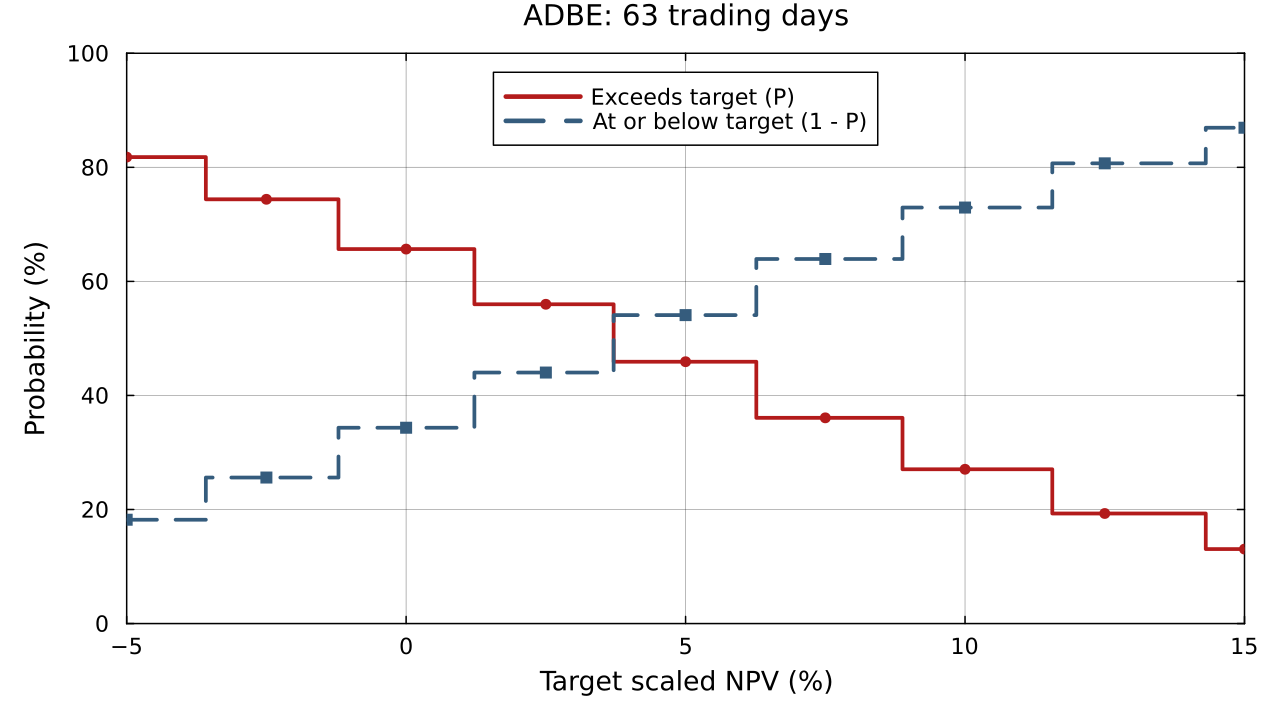

In [23]:
target_probability_plot = let
    # Include the exact terminal-return boundaries so jumps occur at the model's thresholds.
    target_min, target_max = extrema(P[:, 1])
    terminal_returns = [ū^k * d̄^(TSIM-k) * exp(-g_y*TSIM*Δt) - 1 for k ∈ 0:TSIM]
    boundaries = filter(ρ -> target_min <= ρ <= target_max, terminal_returns)
    ρ_plot = sort(unique(vcat(
        collect(range(target_min, target_max; length=401)), boundaries, P[:, 1])))

    # Reuse the same strict target rule used to calculate the table.
    distribution = Binomial(TSIM, p̄)
    exceedance = map(ρ_plot) do ρ_target
        k_min = strict_lattice_threshold(ρ_target, ū, d̄, TSIM, g_y, Δt)
        k_min == 0 ? 1.0 : (k_min > TSIM ? 0.0 : ccdf(distribution, k_min - 1))
    end

    # A strict exceedance probability takes its lower value at each jump.
    fig = plot(100 .* ρ_plot, 100 .* exceedance;
        seriestype=:steppost, linewidth=2.5, color="#b31b1b",
        label="Exceeds target (P)",
        xlabel="Target scaled NPV (%)", ylabel="Probability (%)",
        title="$(selected_firm_ticker): $(TSIM) trading days",
        xlims=(100*target_min, 100*target_max), ylims=(0, 100), yticks=0:20:100,
        legend=:top, legendfontsize=10, guidefontsize=12, tickfontsize=10,
        titlefontsize=13, gridalpha=0.2, framestyle=:box,
        size=(850, 480), dpi=150,
        left_margin=6 * Plots.mm, bottom_margin=6 * Plots.mm,
        top_margin=3 * Plots.mm, right_margin=3 * Plots.mm)
    plot!(fig, 100 .* ρ_plot, 100 .* (1 .- exceedance);
        seriestype=:steppost, linewidth=2.5, linestyle=:dash, color="#355c7d",
        label="At or below target (1 - P)")

    # Mark the tabulated targets without interpolating between them.
    scatter!(fig, 100 .* P[:, 1], 100 .* P[:, 2];
        markershape=:circle, markersize=4, markerstrokewidth=0,
        color="#b31b1b", label="")
    scatter!(fig, 100 .* P[:, 1], 100 .* (1 .- P[:, 2]);
        markershape=:rect, markersize=4, markerstrokewidth=0,
        color="#355c7d", label="")
    fig
end


The solid curve shows the probability of exceeding the target, and the dashed curve shows the probability of finishing at or below it.

___


## Summary
In this example, we used historical stock data to estimate and construct a binomial price lattice. We then applied the NPV framework to compute the probability of exceeding a target return at a scheduled sale time.

> __Key Takeaways__
>
> * **Historical parameter estimation**: We computed annualized log-growth rates from observed stock prices and used them to estimate representative up and down factors and the probability of an up move. These estimates connected our lattice model to historical data.
> * **Binomial lattice construction**: We combined the estimated parameters with an initial share price to build a recombining lattice. This gave us the possible future prices and their probabilities over the selected holding period.
> * **Terminal target probabilities**: We found the minimum number of up moves needed to exceed a target scaled NPV and computed the corresponding binomial probability. We repeated the calculation for several targets and calculated the complementary probabilities of finishing at or below them.

The resulting probabilities depend on our historical sample, chosen benchmark, holding period, and binomial-model assumptions.

___


## Disclaimer and Risks

__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products, or any investment or trading advice or strategy, is made, given, or endorsed by the teaching team.

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.
